# Missing Pixel Image Reconstruction

This notebook explores image reconstruction for missing-pixel restoration using computer vision and deep learning utilities.


In [ ]:
!git clone https://github.com/dmc27/missing_pixels.git

import os, cv2, numpy as np, matplotlib.pyplot as plt
from os.path import join, isfile
from os import listdir

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
plt.rcParams['figure.dpi'] = 110

fatal: destination path 'missing_pixels' already exists and is not an empty directory.


In [ ]:
BLOCK = 8          # patch size
M1, M2 = 3, 4      # missing pixels are rows/cols 3–4 inside each block

def is_missing(r, c):
    return M1 <= r <= M2 and M1 <= c <= M2


In [ ]:
class PatchDataset(Dataset):
    def __init__(self, img_dir, exclude="balloon.bmp"):
        self.x, self.y, self.m = [], [], []
        for fn in listdir(img_dir):
            if fn.lower() == exclude or fn.startswith('.') or not fn.lower().endswith(('.bmp', '.jpg', '.png')):
                continue
            img_path = join(img_dir, fn)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not read image file: {fn}")
                continue
            img = cv2.resize(img, (256, 256), cv2.INTER_LINEAR).astype(np.float32) / 255.0
            self._parse(img)

    def _parse(self, img):
        for r0 in range(0, img.shape[0], BLOCK):
            for c0 in range(0, img.shape[1], BLOCK):
                patch = img[r0:r0+BLOCK, c0:c0+BLOCK].copy()
                mask = np.zeros_like(patch, dtype=np.float32)
                for r in range(BLOCK):
                    for c in range(BLOCK):
                        if is_missing(r, c):
                            mask[r, c] = 1.0
                            patch[r, c] = 0.0  # erase pixel for input
                self.x.append(np.stack([patch, mask]))   # 2×8×8
                self.y.append(img[r0:r0+BLOCK, c0:c0+BLOCK])
                self.m.append(mask)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return (torch.tensor(self.x[idx], dtype=torch.float32),
                torch.tensor(self.y[idx][None, ...], dtype=torch.float32),   # 1×8×8
                torch.tensor(self.m[idx][None, ...], dtype=torch.float32))   # 1×8×8


In [ ]:
class PatchCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),  nn.Sigmoid()   # keep in [0,1]
        )
    def forward(self, x): return self.layers(x)


In [ ]:
def masked_mse(pred, target, mask):
    diff2 = (pred - target).pow(2) * mask           # error only where mask==1
    return diff2.sum() / mask.sum()


In [ ]:
train_ds  = PatchDataset("/content/missing_pixels")
loader    = DataLoader(train_ds, batch_size=512, shuffle=True, pin_memory=True)

net       = PatchCNN().cuda()
opt       = optim.Adam(net.parameters(), lr=2e-3)

for epoch in range(20):
    running = 0.0
    for x, y, m in loader:
        x, y, m = x.cuda(), y.cuda(), m.cuda()
        opt.zero_grad()
        pred = net(x)
        loss = masked_mse(pred, y, m)
        loss.backward()
        opt.step()
        running += loss.item()
    print(f"Epoch {epoch+1:02d}, loss {running/len(loader):.6f}")

Epoch 01, loss 0.008423
Epoch 02, loss 0.003979
Epoch 03, loss 0.003597
Epoch 04, loss 0.003539
Epoch 05, loss 0.003364
Epoch 06, loss 0.003351
Epoch 07, loss 0.003268
Epoch 08, loss 0.003317
Epoch 09, loss 0.003253
Epoch 10, loss 0.003220
Epoch 11, loss 0.003225
Epoch 12, loss 0.003211
Epoch 13, loss 0.003209
Epoch 14, loss 0.003187
Epoch 15, loss 0.003163
Epoch 16, loss 0.003125
Epoch 17, loss 0.003134
Epoch 18, loss 0.003095
Epoch 19, loss 0.003082
Epoch 20, loss 0.003095


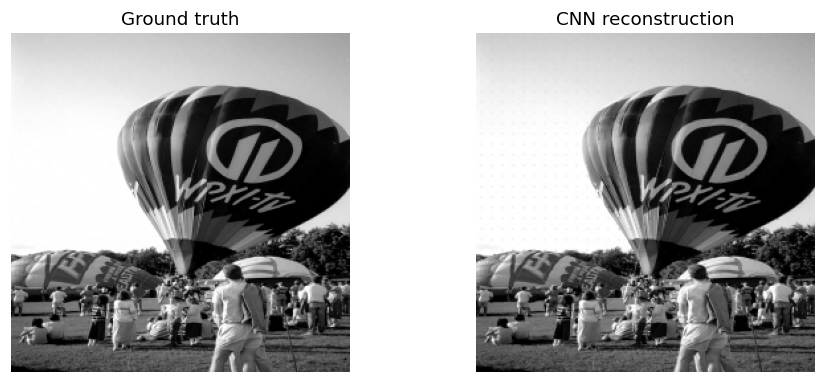

MSE = 0.00019386905


In [ ]:
def reconstruct(net, path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256), cv2.INTER_LINEAR).astype(np.float32)/255.0
    rec = np.zeros_like(img)

    for r0 in range(0, img.shape[0], BLOCK):
        for c0 in range(0, img.shape[1], BLOCK):
            patch   = img[r0:r0+BLOCK, c0:c0+BLOCK].copy()
            mask    = np.zeros_like(patch)
            for r in range(BLOCK):
                for c in range(BLOCK):
                    if is_missing(r, c):
                        mask[r, c], patch[r, c] = 1.0, 0.0
            inp  = torch.tensor(np.stack([patch, mask])[None, ...]).cuda()
            with torch.no_grad():
                out = net(inp).cpu().numpy()[0,0]          # 8×8
            # paste reconstructed pixels
            for r in range(BLOCK):
                for c in range(BLOCK):
                    rec[r0+r, c0+c] = img[r0+r, c0+c] if mask[r,c]==0 else out[r,c]
    return img, rec

gt, pred = reconstruct(net, "/content/missing_pixels/balloon.bmp")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gt,   cmap='gray'); plt.title("Ground truth"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(pred, cmap='gray'); plt.title("CNN reconstruction"); plt.axis('off')
plt.show()
print("MSE =", np.mean((gt - pred)**2))
